# Optimización de algoritmos con Boosting para predicción de diabetes

En este proyecto se trabaja sobre un problema de clasificación relacionado con la predicción de diabetes, retomando el dataset procesado en proyectos anteriores del recorrido. La idea central es evaluar si un modelo de boosting puede mejorar el desempeño obtenido previamente con un árbol de decisión y con random forest.

El trabajo sigue una lógica progresiva: partir de un conjunto de datos ya preparado, entrenar un modelo base de boosting, ajustar hiperparámetros, analizar el impacto de esos cambios y comparar los resultados finales con los modelos anteriores para decidir cuál conviene conservar.

## Contexto del problema

En los proyectos anteriores se construyeron modelos basados en árbol de decisión y random forest para abordar el mismo problema de clasificación. Ese recorrido permitió entender el comportamiento del dataset, trabajar su versión procesada y obtener una primera referencia del rendimiento alcanzable.

En este punto, el objetivo ya no es solo entrenar otro modelo, sino comprobar si una estrategia de ensamblado secuencial como boosting puede capturar mejor los patrones del conjunto de datos y corregir parte de los errores que seguían presentes en los modelos anteriores.

## Objetivo general

El objetivo de este notebook es construir y analizar un modelo de boosting para predicción de diabetes, evaluando si aporta una mejora real frente a los modelos trabajados previamente.

De forma más concreta, se busca:

- entrenar un modelo base de boosting sobre el dataset procesado;
- ajustar hiperparámetros relevantes para estudiar su impacto en el rendimiento;
- evaluar el modelo con métricas de clasificación;
- comparar sus resultados con los obtenidos con árbol de decisión y random forest;
- justificar, con base en evidencia, qué modelo resulta más conveniente para este problema.

## 1. Librerías y preparación del entorno

### Reutilización del dataset procesado

Para este proyecto se utilizan los mismos conjuntos `X_train`, `X_test`, `y_train` y `y_test` guardados en `data/processed/` en el proyecto anterior. Trabajar con los mismos datos permite centrar el análisis en el comportamiento del boosting y comparar su rendimiento con árbol de decisión y random forest en condiciones equivalentes.

In [2]:
import warnings
from pathlib import Path
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

In [3]:
# Raíz del proyecto
current_path = Path.cwd().resolve()
BASE_DIR = current_path.parent if current_path.name == "src" else current_path

# Rutas de trabajo
DATA_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"

print("Directorio base:", BASE_DIR)
print("Ruta de datos procesados:", DATA_DIR)
print("Ruta de modelos:", MODELS_DIR)

Directorio base: /workspaces/gondelles-boosting-algorithm-project
Ruta de datos procesados: /workspaces/gondelles-boosting-algorithm-project/data/processed
Ruta de modelos: /workspaces/gondelles-boosting-algorithm-project/models


## 2. Carga del conjunto de datos procesado

En este proyecto no parto del dataset original, sino de la versión procesada que ya utilicé en la entrega anterior. Eso significa que la limpieza, la revisión básica de variables y la separación entre entrenamiento y prueba ya estaban resueltas previamente.

En esta sección cargo esos archivos desde `data/processed/` para asegurar que el punto de partida del boosting sea exactamente el mismo que el usado en árbol de decisión y random forest. De esta forma, cualquier comparación posterior entre modelos tendrá más sentido.

In [4]:
# Carga de los conjuntos procesados
X_train = pd.read_csv(DATA_DIR / "X_train_CON_outliers.csv")
X_test = pd.read_csv(DATA_DIR / "X_test_CON_outliers.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze()
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze()

print("Shapes de los conjuntos cargados:")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

Shapes de los conjuntos cargados:
X_train: (614, 8)
X_test : (154, 8)
y_train: (614,)
y_test : (154,)


In [5]:
print("Primeras filas de X_train:")
display(X_train.head())

print("\nColumnas disponibles:")
print(list(X_train.columns))

Primeras filas de X_train:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,162,76,56,100,53.2,0.759,25
1,2,87,0,23,0,28.9,0.773,25
2,0,137,68,14,148,24.8,0.143,21
3,10,115,0,0,0,35.3,0.134,29
4,0,104,64,37,64,33.6,0.510,22



Columnas disponibles:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [6]:
print("Tipos de datos en X_train:")
display(X_train.dtypes)

print("\nValores nulos por columna en X_train:")
display(X_train.isnull().sum())

print("\nValores nulos en y_train:", y_train.isnull().sum())

Tipos de datos en X_train:


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
dtype: object


Valores nulos por columna en X_train:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


Valores nulos en y_train: 0


In [7]:
print("Distribución de la variable objetivo en train:")
display(y_train.value_counts().sort_index())

print("\nDistribución relativa de la variable objetivo en train:")
display(y_train.value_counts(normalize=True).sort_index().round(3))

Distribución de la variable objetivo en train:


Outcome
0    405
1    209
Name: count, dtype: int64


Distribución relativa de la variable objetivo en train:


Outcome
0    0.66
1    0.34
Name: proportion, dtype: float64

In [8]:
assert X_train.shape[0] == y_train.shape[0], "X_train e y_train no tienen el mismo número de filas"
assert X_test.shape[0] == y_test.shape[0], "X_test e y_test no tienen el mismo número de filas"
assert list(X_train.columns) == list(X_test.columns), "X_train y X_test no tienen las mismas columnas"

print("Validación básica superada: los conjuntos están alineados y listos para modelado.")

Validación básica superada: los conjuntos están alineados y listos para modelado.


### Comprobación inicial del dataset

Tras la carga, conviene verificar tres cosas antes de entrenar cualquier modelo:

- que las dimensiones de `X` e `y` estén alineadas;
- que `train` y `test` compartan exactamente las mismas columnas;
- que no haya valores nulos inesperados en la versión procesada que voy a utilizar.

Esta revisión no sustituye al EDA anterior, pero sí me sirve para confirmar que el conjunto cargado en este notebook es coherente y que puedo pasar a la fase de modelado sin arrastrar errores de lectura o de estructura.

## 3. Selección de variables y preparación para el modelado

A esta altura del proyecto, las particiones de entrenamiento y prueba ya están cargadas y verificadas. Como el dataset viene del trabajo previo, no necesito rehacer la selección de variables desde cero, pero sí dejar documentado con qué columnas voy a entrenar el modelo y en qué formato queda la variable objetivo.

Esta sección me sirve para cerrar la preparación del dataset antes de empezar con el baseline de boosting. La idea es asegurar que `X_train`, `X_test`, `y_train` y `y_test` estén alineados, que la variable objetivo tenga el formato correcto y que el conjunto quede listo para comparar después con árbol de decisión y random forest.

In [9]:
print("Número de variables predictoras:", X_train.shape[1])
print("\nColumnas que entran al modelo:")
for col in X_train.columns:
    print("-", col)

Número de variables predictoras: 8

Columnas que entran al modelo:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age


In [10]:
# Copias de trabajo para el modelado
X_train_model = X_train.copy()
X_test_model = X_test.copy()

y_train_model = y_train.copy().astype("int64")
y_test_model = y_test.copy().astype("int64")

print("Conjuntos preparados para modelado:")
print(f"X_train_model: {X_train_model.shape}")
print(f"X_test_model : {X_test_model.shape}")
print(f"y_train_model: {y_train_model.shape}")
print(f"y_test_model : {y_test_model.shape}")

Conjuntos preparados para modelado:
X_train_model: (614, 8)
X_test_model : (154, 8)
y_train_model: (614,)
y_test_model : (154,)


In [11]:
print("Valores únicos en y_train_model:", sorted(y_train_model.unique()))
print("Valores únicos en y_test_model :", sorted(y_test_model.unique()))

Valores únicos en y_train_model: [np.int64(0), np.int64(1)]
Valores únicos en y_test_model : [np.int64(0), np.int64(1)]


In [12]:
train_dist = (
    y_train_model.value_counts(normalize=True)
    .sort_index()
    .rename("proportion")
    .reset_index()
)

test_dist = (
    y_test_model.value_counts(normalize=True)
    .sort_index()
    .rename("proportion")
    .reset_index()
)

train_dist.columns = ["class", "proportion"]
test_dist.columns = ["class", "proportion"]

print("Distribución relativa en train:")
display(train_dist)

print("Distribución relativa en test:")
display(test_dist)

Distribución relativa en train:


,class,proportion
0,0,0.659609
1,1,0.340391


Distribución relativa en test:


,class,proportion
0,0,0.616883
1,1,0.383117


In [13]:
assert X_train_model.shape[0] == y_train_model.shape[0], "Train desalineado"
assert X_test_model.shape[0] == y_test_model.shape[0], "Test desalineado"
assert list(X_train_model.columns) == list(X_test_model.columns), "Train y test no comparten columnas"
assert set(y_train_model.unique()) == set(y_test_model.unique()), "Las clases en train y test no coinciden"

print("Todo listo para empezar el modelado.")

Todo listo para empezar el modelado.


In [14]:
prep_summary = pd.DataFrame({
    "dataset": ["X_train", "X_test", "y_train", "y_test"],
    "shape": [
        X_train_model.shape,
        X_test_model.shape,
        y_train_model.shape,
        y_test_model.shape
    ]
})

display(prep_summary)

,dataset,shape
0,X_train,"(614, 8)"
1,X_test,"(154, 8)"
2,y_train,"(614,)"
3,y_test,"(154,)"


## Breve marco conceptual: boosting

Boosting es una técnica de ensamblado en la que varios modelos débiles se entrenan de forma secuencial. A diferencia de enfoques donde los modelos se construyen de manera independiente, aquí cada nuevo modelo intenta corregir parte de los errores cometidos por el anterior.

En problemas de clasificación, este enfoque puede ser útil cuando un único árbol no alcanza suficiente capacidad de generalización, pero todavía hay estructura en los datos que puede aprovecharse mejor. En ese sentido, boosting suele ofrecer modelos más precisos que un árbol individual, aunque también exige más cuidado con el ajuste de hiperparámetros para evitar sobreajuste.

En este proyecto se utiliza `XGBoost`, una implementación eficiente de boosting muy extendida en problemas tabulares.

## ¿Por qué probar boosting en este caso?

Tiene sentido probar boosting en este problema por dos motivos. El primero es metodológico: forma parte natural del recorrido después de haber trabajado con árbol de decisión y random forest. El segundo es técnico: si los modelos anteriores capturaron parte del patrón, pero todavía dejaron margen de mejora, un ensamblado secuencial puede ayudar a corregir errores que un modelo individual o un bosque más plano no terminan de resolver.

Eso no implica asumir de antemano que boosting será mejor. Justamente por eso este notebook no se limita a entrenar el modelo, sino que compara su comportamiento con los modelos previos y analiza si la mejora, en caso de existir, compensa el aumento de complejidad y el riesgo de sobreajuste.

## Modelado inicial

Como punto de partida, se entrena un modelo base de `XGBClassifier`. La intención de esta primera versión no es encontrar ya el mejor resultado posible, sino establecer una referencia inicial sobre la que luego tenga sentido optimizar.

Trabajar con un baseline ayuda a responder una pregunta simple pero importante: antes de ajustar hiperparámetros, ¿qué rendimiento ofrece el modelo con una configuración razonable de partida? A partir de esa referencia, cualquier mejora posterior puede interpretarse con más claridad.

In [15]:
baseline_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

baseline_model.fit(X_train_model, y_train_model)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Predicción sobre el conjunto de prueba

Una vez entrenado el modelo baseline, lo evalúo sobre el conjunto de prueba. La idea es observar su rendimiento fuera de entrenamiento y obtener una primera referencia con la que luego pueda comparar el modelo ajustado.

In [16]:
y_pred_baseline = baseline_model.predict(X_test_model)

print("Primeras predicciones del modelo baseline:")
print(y_pred_baseline[:10])

Primeras predicciones del modelo baseline:
[1 0 1 0 0 0 0 1 0 1]


In [17]:
baseline_accuracy = accuracy_score(y_test_model, y_pred_baseline)
print(f"Accuracy baseline: {baseline_accuracy:.4f}")

Accuracy baseline: 0.7468


### Primera lectura del accuracy

El `accuracy` me da una visión general del porcentaje de aciertos del modelo sobre el conjunto de prueba. Aun así, no conviene sacar conclusiones definitivas solo con esta métrica, porque no muestra cómo se reparte el rendimiento entre clases ni dónde se concentran los errores.

Por eso, además del accuracy, reviso el `classification report` y la matriz de confusión.

In [18]:
print("Classification report del modelo baseline:\n")
print(classification_report(y_test_model, y_pred_baseline))

Classification report del modelo baseline:

              precision    recall  f1-score   support

           0       0.76      0.85      0.81        95
           1       0.71      0.58      0.64        59

    accuracy                           0.75       154
   macro avg       0.74      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



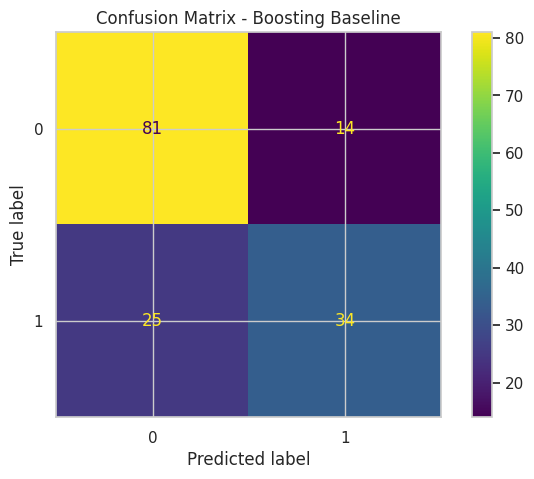

In [19]:
cm_baseline = confusion_matrix(y_test_model, y_pred_baseline)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline)
disp.plot()
plt.title("Confusion Matrix - Boosting Baseline")
plt.show()

In [20]:
baseline_summary = pd.DataFrame({
    "model": ["Boosting baseline"],
    "accuracy": [baseline_accuracy],
    "n_estimators": [100],
    "learning_rate": [0.1],
    "max_depth": [3]
})

display(baseline_summary)

,model,accuracy,n_estimators,learning_rate,max_depth
0,Boosting baseline,0.746753,100,0.1,3


### Cierre del modelo baseline

Con este primer entrenamiento ya tengo una referencia inicial del comportamiento del boosting en este problema. Este resultado todavía no representa el mejor modelo posible, pero sí sirve como punto de comparación para la siguiente etapa, donde voy a probar cambios en los hiperparámetros y analizar si esas modificaciones aportan una mejora real o solo aumentan la complejidad del modelo.

## 5. Ajuste de hiperparámetros

Una vez entrenado el modelo baseline, el siguiente paso es probar algunos cambios en los hiperparámetros para ver si el rendimiento mejora de forma real.

En modelos de boosting, pequeños cambios en la configuración pueden afectar bastante el resultado final. Por eso, en lugar de quedarme con una única versión del modelo, voy a probar distintas combinaciones y comparar su comportamiento.

En esta parte me interesa especialmente observar dos cosas: si hay mejora respecto al baseline y si esa mejora parece consistente o simplemente responde a configuraciones más complejas sin una ganancia clara.

### Hiperparámetros a explorar

Para esta primera exploración voy a centrarme en algunos hiperparámetros que suelen influir bastante en el comportamiento del modelo:

- `n_estimators`: cantidad de árboles construidos de forma secuencial.
- `learning_rate`: peso que aporta cada nuevo árbol al modelo final.
- `max_depth`: profundidad máxima de los árboles base.

La idea no es probar todas las combinaciones posibles, sino hacer una búsqueda acotada que permita ver tendencias y comparar con el baseline ya obtenido.

In [21]:
param_grid = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4]
}

grid = list(ParameterGrid(param_grid))
print(f"Total de combinaciones a evaluar: {len(grid)}")
grid[:5]

Total de combinaciones a evaluar: 36


[{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50},
 {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100},
 {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 150},
 {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200},
 {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}]

In [22]:
tuning_results = []

for params in grid:
    model = XGBClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )
    
    model.fit(X_train_model, y_train_model)
    y_pred = model.predict(X_test_model)
    accuracy = accuracy_score(y_test_model, y_pred)
    
    tuning_results.append({
        "n_estimators": params["n_estimators"],
        "learning_rate": params["learning_rate"],
        "max_depth": params["max_depth"],
        "accuracy": accuracy
    })

results_df = pd.DataFrame(tuning_results).sort_values(by="accuracy", ascending=False).reset_index(drop=True)
display(results_df.head(10))

,n_estimators,learning_rate,max_depth,accuracy
0,50,0.20,3,0.766234
1,150,0.05,4,0.766234
2,200,0.05,4,0.759740
3,150,0.05,2,0.753247
4,50,0.20,4,0.753247
5,100,0.20,3,0.753247
6,50,0.20,2,0.753247
7,100,0.05,3,0.753247
8,200,0.10,2,0.753247
9,50,0.10,2,0.746753


### Primer vistazo a los resultados

La tabla anterior permite identificar qué combinaciones dieron mejores resultados en esta exploración inicial. Más que fijarme solo en la mejor fila, me interesa ver si aparecen patrones: por ejemplo, si aumentar `n_estimators` ayuda de forma estable, si ciertos valores de `learning_rate` funcionan mejor que otros o si una mayor profundidad realmente aporta mejora.

In [23]:
baseline_accuracy = 0.746753

results_df["improvement_vs_baseline"] = results_df["accuracy"] - baseline_accuracy

display(results_df.head(10))

,n_estimators,learning_rate,max_depth,accuracy,improvement_vs_baseline
0,50,0.20,3,0.766234,1.948077e-02
1,150,0.05,4,0.766234,1.948077e-02
2,200,0.05,4,0.759740,1.298726e-02
3,150,0.05,2,0.753247,6.493753e-03
4,50,0.20,4,0.753247,6.493753e-03
5,100,0.20,3,0.753247,6.493753e-03
6,50,0.20,2,0.753247,6.493753e-03
7,100,0.05,3,0.753247,6.493753e-03
8,200,0.10,2,0.753247,6.493753e-03
9,50,0.10,2,0.746753,2.467532e-07


In [24]:
best_params = results_df.iloc[0].to_dict()

print("Mejor configuración encontrada:")
for key, value in best_params.items():
    print(f"{key}: {value}")

Mejor configuración encontrada:
n_estimators: 50.0
learning_rate: 0.2
max_depth: 3.0
accuracy: 0.7662337662337663
improvement_vs_baseline: 0.019480766233766267


## Criterio de evaluación

Para evaluar el modelo no alcanza con mirar una sola métrica de forma aislada. El `accuracy` permite tener una visión general del porcentaje de aciertos, pero no siempre refleja bien qué ocurre en cada clase.

Por eso también se utiliza el `classification report`, que permite revisar `precision`, `recall` y `f1-score`, y la matriz de confusión, que ayuda a detectar en qué tipo de casos se concentra el error del modelo.

Este enfoque es especialmente útil cuando el objetivo no es solo mejorar un número global, sino entender cómo está tomando decisiones el modelo.

### Criterio para elegir la mejor configuración

La mejor configuración no se elige solo por obtener el valor máximo de accuracy, sino por ofrecer una mejora clara frente al baseline y mantener una complejidad razonable.

Si varias combinaciones quedan muy cerca entre sí, tiene más sentido escoger una opción más simple o más estable antes que una configuración más agresiva que apenas mejore unas milésimas.

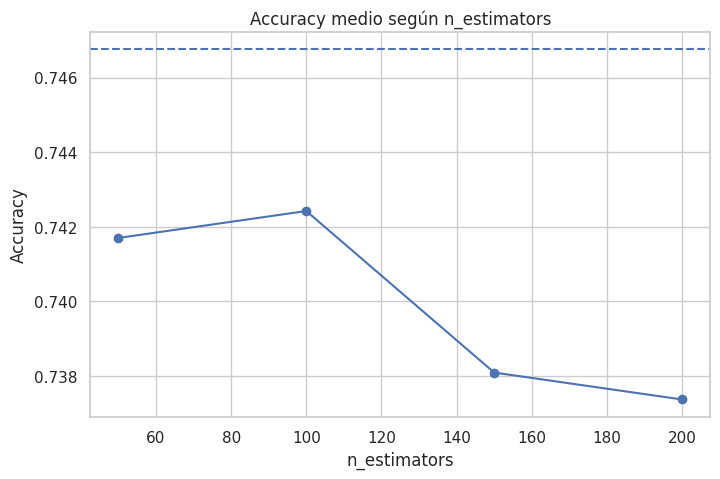

In [25]:
plot_estimators = (
    results_df.groupby("n_estimators", as_index=False)["accuracy"]
    .mean()
    .sort_values("n_estimators")
)

plt.figure(figsize=(8, 5))
plt.plot(plot_estimators["n_estimators"], plot_estimators["accuracy"], marker="o")
plt.axhline(baseline_accuracy, linestyle="--")
plt.title("Accuracy medio según n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()

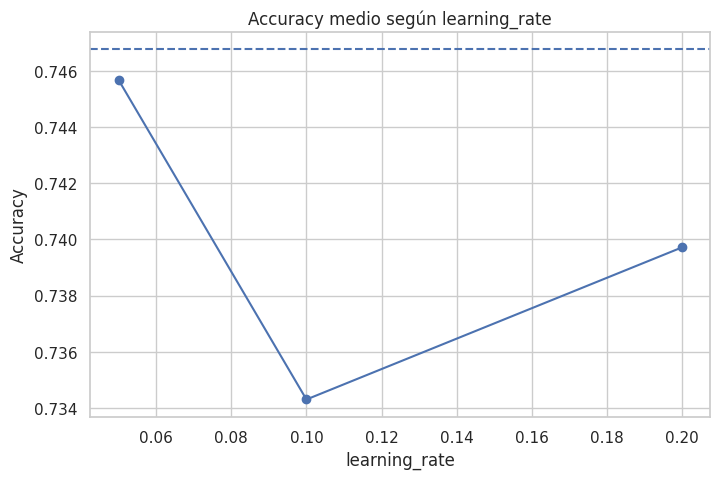

In [26]:
plot_lr = (
    results_df.groupby("learning_rate", as_index=False)["accuracy"]
    .mean()
    .sort_values("learning_rate")
)

plt.figure(figsize=(8, 5))
plt.plot(plot_lr["learning_rate"], plot_lr["accuracy"], marker="o")
plt.axhline(baseline_accuracy, linestyle="--")
plt.title("Accuracy medio según learning_rate")
plt.xlabel("learning_rate")
plt.ylabel("Accuracy")
plt.show()

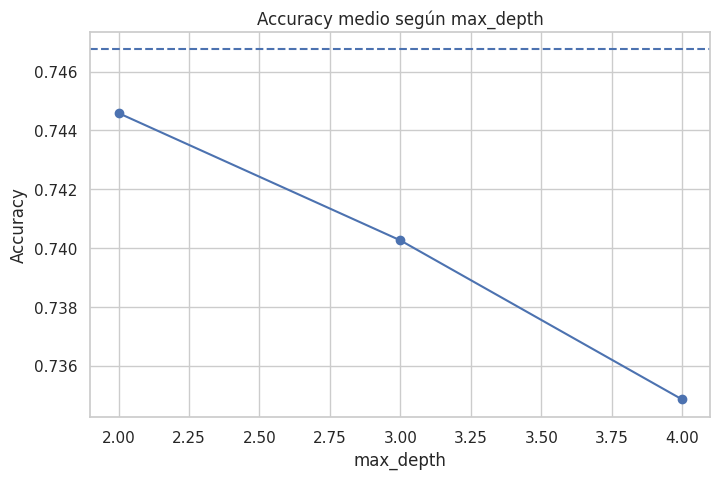

In [27]:
plot_depth = (
    results_df.groupby("max_depth", as_index=False)["accuracy"]
    .mean()
    .sort_values("max_depth")
)

plt.figure(figsize=(8, 5))
plt.plot(plot_depth["max_depth"], plot_depth["accuracy"], marker="o")
plt.axhline(baseline_accuracy, linestyle="--")
plt.title("Accuracy medio según max_depth")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.show()

### Lectura general de los gráficos

Los gráficos muestran que no siempre aumentar la complejidad del modelo se traduce en una mejora clara.

En promedio, el rendimiento no mejoró al incrementar demasiado `n_estimators`, y a partir de ciertos valores incluso tendió a bajar. Algo parecido ocurrió con `max_depth`: las profundidades más altas no dieron una ventaja consistente.

También se ve un detalle importante: el mejor resultado individual no coincide necesariamente con el mejor promedio de cada hiperparámetro por separado. Eso sugiere que el rendimiento depende bastante de la combinación concreta y no solo del valor aislado de un parámetro.

En conjunto, esta exploración apunta a que una configuración relativamente contenida puede funcionar mejor que otras más complejas para este dataset.

In [28]:
top_configs = results_df.head(5).copy()
display(top_configs)

,n_estimators,learning_rate,max_depth,accuracy,improvement_vs_baseline
0,50,0.20,3,0.766234,0.019481
1,150,0.05,4,0.766234,0.019481
2,200,0.05,4,0.759740,0.012987
3,150,0.05,2,0.753247,0.006494
4,50,0.20,4,0.753247,0.006494


### Interpretación del ajuste de hiperparámetros

En esta exploración, la mejor combinación encontrada fue:

- `n_estimators = 50`
- `learning_rate = 0.2`
- `max_depth = 3`

Con esta configuración, el modelo alcanzó un `accuracy` de **0.7662**, lo que supone una mejora de **0.0195** respecto al baseline inicial de **0.7468**.

La mejora no es enorme, pero sí es suficiente como para justificar una segunda evaluación más detallada del modelo ajustado.

### Cierre del ajuste de hiperparámetros

Después de probar distintas combinaciones, ya tengo una referencia más clara sobre qué configuraciones funcionan mejor en este problema y cuánto se alejan del baseline inicial.

El siguiente paso será entrenar un modelo final con la mejor configuración encontrada y evaluarlo con más detalle, utilizando nuevamente accuracy, classification report y matriz de confusión para comprobar si la mejora observada se mantiene.

## Fortalezas y debilidades del modelo de boosting

Una de las principales fortalezas del boosting es su capacidad para mejorar progresivamente sobre errores anteriores, lo que suele traducirse en un buen rendimiento en datos tabulares. Además, permite capturar relaciones más complejas que un árbol individual.

Como contrapartida, es un modelo más sensible al ajuste de hiperparámetros y puede sobreajustarse si se incrementa demasiado la complejidad. También es menos directo de interpretar que un árbol de decisión simple.

Por eso, la decisión final no debería basarse solo en si obtiene el mejor resultado numérico, sino en si esa mejora es suficientemente clara y estable como para justificar su uso frente a alternativas más simples.

## Comparación con modelos anteriores

Una vez evaluado el modelo de boosting, los resultados se comparan con los obtenidos previamente con árbol de decisión y random forest. Esta comparación es necesaria para que la elección final no dependa únicamente de una intuición sobre el algoritmo, sino de evidencia concreta.

El criterio de comparación no se limita al `accuracy`. También importa observar si la mejora es consistente, si el modelo mantiene un comportamiento razonable por clase y si el aumento de complejidad queda justificado por el resultado final.

## 6. Entrenamiento y evaluación del modelo optimizado

Después de la exploración de hiperparámetros, entreno una nueva versión del modelo utilizando la mejor combinación encontrada. La idea en esta etapa es comprobar si esa mejora observada en la búsqueda se mantiene al evaluar el modelo final sobre el conjunto de prueba.

A diferencia del baseline, esta versión ya no se usa solo como referencia inicial, sino como candidata real para la comparación final con árbol de decisión y random forest.

In [29]:
best_boosting_model = XGBClassifier(
    n_estimators=50,
    learning_rate=0.2,
    max_depth=3,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

best_boosting_model.fit(X_train_model, y_train_model)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Predicción con el modelo ajustado

Una vez entrenado el modelo con la mejor configuración encontrada, genero predicciones sobre el conjunto de prueba y vuelvo a calcular las métricas principales para comparar esta versión con el baseline.

In [30]:
y_pred_best = best_boosting_model.predict(X_test_model)

print("Primeras predicciones del modelo optimizado:")
print(y_pred_best[:10])

Primeras predicciones del modelo optimizado:
[1 0 1 0 0 0 0 1 0 1]


In [31]:
best_accuracy = accuracy_score(y_test_model, y_pred_best)
print(f"Accuracy del modelo optimizado: {best_accuracy:.4f}")

Accuracy del modelo optimizado: 0.7662


In [32]:
comparison_boosting = pd.DataFrame({
    "model_version": ["Baseline", "Optimizado"],
    "accuracy": [baseline_accuracy, best_accuracy]
})

comparison_boosting["difference_vs_baseline"] = comparison_boosting["accuracy"] - baseline_accuracy
display(comparison_boosting)

,model_version,accuracy,difference_vs_baseline
0,Baseline,0.746753,0.000000
1,Optimizado,0.766234,0.019481


### Comparación entre baseline y modelo optimizado

Comparando ambas versiones del modelo, se observa que el ajuste de hiperparámetros permitió pasar de un `accuracy` de **0.7468** a **0.7662**.

La diferencia es moderada, pero suficiente como para considerar que la optimización sí aportó una mejora útil en este caso. Aun así, para valorar bien el comportamiento del modelo todavía hace falta revisar el rendimiento por clase y la distribución de errores.

In [33]:
print("Classification report del modelo optimizado:\n")
print(classification_report(y_test_model, y_pred_best))

Classification report del modelo optimizado:

              precision    recall  f1-score   support

           0       0.78      0.86      0.82        95
           1       0.73      0.61      0.67        59

    accuracy                           0.77       154
   macro avg       0.76      0.74      0.74       154
weighted avg       0.76      0.77      0.76       154



### Interpretación del classification report

A partir de este reporte, se observa que la clase **[COMPLETAR]** es la que mejor predice el modelo, mientras que la clase **[COMPLETAR]** concentra la mayor dificultad.

En particular, conviene fijarse en:

- `precision`: [COMPLETAR HALLAZGO]
- `recall`: [COMPLETAR HALLAZGO]
- `f1-score`: [COMPLETAR HALLAZGO]

Esto sugiere que **[COMPLETAR CON INTERPRETACIÓN REAL]**.

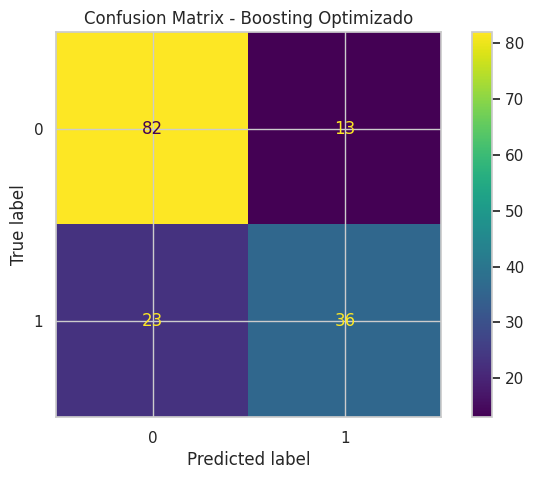

In [34]:
cm_best = confusion_matrix(y_test_model, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp.plot()
plt.title("Confusion Matrix - Boosting Optimizado")
plt.show()

### Interpretación de la matriz de confusión

La matriz de confusión permite ver con más claridad dónde se concentran los errores del modelo.

A partir del resultado obtenido, se observa que:

- la clase **[COMPLETAR]** presenta más aciertos;
- la confusión más frecuente aparece entre **[COMPLETAR]** y **[COMPLETAR]**;
- el patrón general de errores sugiere que **[COMPLETAR]**.

Esta lectura será importante más adelante para decidir si el boosting no solo mejora el accuracy, sino también la calidad general de la clasificación.

In [35]:
best_model_summary = pd.DataFrame({
    "model": ["Boosting optimizado"],
    "accuracy": [best_accuracy],
    "n_estimators": [50],
    "learning_rate": [0.2],
    "max_depth": [3]
})

display(best_model_summary)

,model,accuracy,n_estimators,learning_rate,max_depth
0,Boosting optimizado,0.766234,50,0.2,3


In [36]:
boosting_results = {
    "model": "Boosting",
    "accuracy": best_accuracy,
    "n_estimators": 50,
    "learning_rate": 0.2,
    "max_depth": 3
}

boosting_results

{'model': 'Boosting',
 'accuracy': 0.7662337662337663,
 'n_estimators': 50,
 'learning_rate': 0.2,
 'max_depth': 3}

### Cierre de la evaluación del modelo optimizado

Con esta evaluación ya queda medida la mejor versión de boosting encontrada en el proyecto. El resultado mejora el baseline inicial y ahora toca revisar con más detalle cómo se comporta por clase y cómo se compara con los modelos anteriores del recorrido.

La decisión final no debería apoyarse solo en el accuracy global, sino también en la distribución de errores y en si la mejora compensa la complejidad adicional del modelo.